# 03. Базовые модели и сильные табличные ориентиры

Вопрос: насколько доступны для прогноза первого запуска история учащегося и описание следующего задания? Все модели используют одну и ту же выборку, одинаковые групповые фолды и определение цели из первых двух блокнотов.

Основная метрика — LogLoss (меньше лучше); дополнительные — AUROC и average precision (больше лучше), Brier (меньше лучше). Два заранее заданных варианта настройки каждого обучаемого семейства сравниваются по pooled OOF LogLoss на трёх фолдах учащихся, seed 17. Для выбранной конфигурации оцениваются seeds 17, 42, 2026. Импутация, масштабирование и кодирование обучаются заново внутри каждого training-fold.

OOF используется для выбора конфигурации и последующего stacking; это не независимая оценка после настройки. Validation содержит других учащихся и служит для сравнения семейств. Закрытый тест не загружается. Выборка не балансируется: прогноз должен сохранять наблюдаемую частоту исходов.

In [1]:
from pathlib import Path
import json
import hashlib


def verify_frozen_training_source(root: Path) -> None:
    """Verify frozen training code before reproducing the recorded evaluation."""
    boundary = root / "dataset/protocol/test_evaluation_boundary.json"
    if not boundary.exists():
        return
    frozen_sources = json.loads(
        (root / "dataset/protocol/frozen_training_sources.json").read_text()
    )
    for filename, expected in frozen_sources["notebooks"].items():
        notebook = json.loads((root / "notebooks" / filename).read_text())
        source = "\n\n".join(
            "".join(cell["source"])
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
        )
        observed = hashlib.sha256(source.encode()).hexdigest()
        assert (
            observed == expected
        ), "Training source changed after the test was opened."


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown


def resolve_project_root(start: Path) -> Path:
    """Find the repository from its root or any notebook subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "dataset/raw").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Start Jupyter from the GraphProg repository or its notebooks directory."
    )


ROOT = resolve_project_root(Path.cwd())
for relative in (
    "dataset/processed",
    "dataset/protocol",
    "artifacts/runtime",
    "figures/generated",
):
    (ROOT / relative).mkdir(parents=True, exist_ok=True)

SEED = 20260923
rng = np.random.default_rng(SEED)
font_names = {font.name for font in font_manager.fontManager.ttflist}
assert "Times New Roman" in font_names
FONT = "Times New Roman"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
mpl.rcParams.update(
    {
        "font.family": FONT,
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 350,
        "savefig.dpi": 350,
        "axes.unicode_minus": True,
        "mathtext.fontset": "stix",
    }
)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


def table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Display a complete DataFrame using Jupyter's default table styling."""
    frame.to_csv(ROOT / "artifacts" / f"{name}.csv", index=False)
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.max_colwidth",
        None,
        "display.width",
        None,
    ):
        display(Markdown(caption))
        display(frame.reset_index(drop=True).round(3))


def save_figure(fig: mpl.figure.Figure, name: str) -> None:
    """Save at 350 dpi after checking the font contract on visible text."""
    from matplotlib.text import Text

    fig.canvas.draw()
    for text in fig.findobj(match=Text):
        if text.get_visible() and text.get_text():
            assert 18 <= text.get_fontsize() <= 20
            assert text.get_fontfamily() == ["Times New Roman"]
    fig.savefig(ROOT / "figures/generated" / f"{name}.png", dpi=FIGURE_DPI)
    fig.savefig(ROOT / "figures/generated" / f"{name}.pdf", dpi=FIGURE_DPI)


import time
import joblib
from typing import Any
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.calibration import calibration_curve
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

protocol = json.loads(
    (ROOT / "dataset/protocol/robomission_protocol.json").read_text()
)
verify_frozen_training_source(ROOT)
verify_frozen_training_source(ROOT)
assert (
    not protocol["locked_test_opened"]
    or (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists()
    or (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists()
)
contract = json.loads(
    (ROOT / "dataset/protocol/robo_feature_contract.json").read_text()
)
train_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_train.pkl"
).reset_index(drop=True)
validation_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_validation.pkl"
).reset_index(drop=True)
feature_names = contract["features"]
numeric_names = [
    name for name in feature_names if name not in contract["categorical"]
]
assert set(train_data.student).isdisjoint(validation_data.student)
assert train_data.groupby("student").fold.nunique().eq(1).all()
MODEL_DIR = ROOT / "artifacts/runtime/baselines"
MODEL_DIR.mkdir(exist_ok=True)
SEEDS = [17, 42, 2026]
PROBABILITY_EPSILON = 1e-6
CANDIDATES = {
    "LogisticRegression": [{"C": 0.1}, {"C": 1.0}],
    "RandomForest": [{"max_depth": 8}, {"max_depth": 14}],
    "XGBoost": [{"max_depth": 3}, {"max_depth": 5}],
    "LightGBM": [{"num_leaves": 15}, {"num_leaves": 31}],
}
selected_configurations, candidate_predictions = {}, {}
selection_rows, efficiency_rows = [], []
all_predictions, all_metrics = [], []

assert contract["feature_revision"] == "event_prefix_v2"
assert (
    train_data.attrs["feature_revision"]
    == validation_data.attrs["feature_revision"]
    == "event_prefix_v2"
)


## Реализация общего протокола

Функции ниже выполняют одну и ту же процедуру для всех семейств. Идентификатор учащегося не является входом модели. Учебные и валидационные строки сохраняют свои исходные идентификаторы для последующих парных сравнений.

In [2]:
def probability_metrics(
    target: np.ndarray, probability: np.ndarray
) -> dict[str, float]:
    """Calculate prespecified classification metrics on finite probabilities."""
    assert np.isfinite(probability).all()
    assert np.logical_and(probability >= 0, probability <= 1).all()
    clipped = np.clip(
        probability, PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON
    )
    return {
        "LogLoss": log_loss(target, clipped, labels=[0, 1]),
        "AUROC": roc_auc_score(target, clipped),
        "AP": average_precision_score(target, clipped),
        "Brier": brier_score_loss(target, clipped),
    }


def make_preprocessor() -> ColumnTransformer:
    """Create a fresh fold-local numerical and categorical transformation."""
    numeric = make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True), StandardScaler()
    )
    categorical = OneHotEncoder(
        handle_unknown="ignore", sparse_output=False, dtype=np.float32
    )
    return ColumnTransformer(
        [
            ("numeric", numeric, numeric_names),
            ("task", categorical, ["problem"]),
        ],
        sparse_threshold=0,
    )


def transformed_frame(values: np.ndarray) -> pd.DataFrame:
    """Use stable neutral column names for all estimator implementations."""
    return pd.DataFrame(
        values.astype(np.float32),
        columns=[f"x{i:03d}" for i in range(values.shape[1])],
    )


def make_estimator(model_name: str, settings: dict, seed: int) -> Any:
    """Construct one model under the declared fixed training budget."""
    if model_name == "LogisticRegression":
        return LogisticRegression(
            **settings,
            solver="lbfgs",
            max_iter=2000,
            tol=1e-5,
            random_state=seed,
        )
    if model_name == "RandomForest":
        return RandomForestClassifier(
            **settings,
            n_estimators=120,
            min_samples_leaf=20,
            n_jobs=2,
            random_state=seed,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            **settings,
            n_estimators=220,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=2,
            tree_method="hist",
            n_jobs=2,
            random_state=seed,
            verbosity=0,
        )
    if model_name == "LightGBM":
        return LGBMClassifier(
            **settings,
            n_estimators=220,
            learning_rate=0.05,
            min_child_samples=30,
            reg_lambda=2,
            colsample_bytree=0.9,
            n_jobs=2,
            random_state=seed,
            verbosity=-1,
            deterministic=True,
            force_col_wise=True,
        )
    raise ValueError(f"Unknown model: {model_name}")


def crossfit(
    model_name: str, settings: dict, seed: int
) -> tuple[np.ndarray, float]:
    """Predict each training learner using models fitted on other learners."""
    out_of_fold = np.full(len(train_data), np.nan)
    seconds = 0.0
    for fold in sorted(train_data.fold.unique()):
        held_out = train_data.fold.eq(fold).to_numpy()
        fit_rows, held_rows = (
            train_data.loc[~held_out],
            train_data.loc[held_out],
        )
        assert set(fit_rows.student).isdisjoint(held_rows.student)
        preprocessing = make_preprocessor()
        started = time.perf_counter()
        fit_matrix = transformed_frame(
            preprocessing.fit_transform(fit_rows[feature_names])
        )
        held_matrix = transformed_frame(
            preprocessing.transform(held_rows[feature_names])
        )
        estimator = make_estimator(model_name, settings, seed)
        estimator.fit(fit_matrix, fit_rows.y.to_numpy())
        seconds += time.perf_counter() - started
        out_of_fold[held_out] = estimator.predict_proba(held_matrix)[:, 1]
    assert np.isfinite(out_of_fold).all()
    return out_of_fold, seconds


def tune_family(model_name: str) -> pd.DataFrame:
    """Compare two fixed candidates and retain their complete OOF predictions."""
    rows = []
    for candidate, settings in enumerate(CANDIDATES[model_name]):
        predicted, seconds = crossfit(model_name, settings, SEEDS[0])
        candidate_predictions[(model_name, candidate)] = predicted
        metrics = probability_metrics(train_data.y.to_numpy(), predicted)
        rows.append(
            {
                "Model": model_name,
                "Split": "Train OOF",
                "n": len(train_data),
                "Candidate": candidate,
                "Configuration": json.dumps(settings),
                "LogLoss ↓": metrics["LogLoss"],
                "Brier ↓": metrics["Brier"],
            }
        )
        selection_rows.append(
            {
                "model": model_name,
                "candidate": candidate,
                "settings": settings,
                "oof_seconds": seconds,
                **metrics,
            }
        )
    best = min(rows, key=lambda row: row["LogLoss ↓"])["Candidate"]
    selected_configurations[model_name] = CANDIDATES[model_name][best]
    return pd.DataFrame(rows)


def record_predictions(
    model_name: str,
    split: str,
    seed: int,
    rows: pd.DataFrame,
    probability: np.ndarray,
) -> None:
    """Keep aligned predictions and exact per-seed metrics for downstream analysis."""
    prediction = rows[["id", "student", "problem", "y", "fold"]].copy()
    prediction["model"], prediction["split"], prediction["seed"] = (
        model_name,
        split,
        seed,
    )
    prediction["probability"] = probability
    all_predictions.append(prediction)
    all_metrics.append(
        {
            "Model": model_name,
            "Split": split,
            "Seed": seed,
            "n": len(rows),
            **probability_metrics(rows.y.to_numpy(), probability),
        }
    )


## Простые вероятностные ориентиры

Насколько полезны общая частота успеха и сложность задания без истории ученика? Оценка задания сглаживается к общей частоте с заранее фиксированным весом 20 наблюдений. Во всех OOF-прогнозах частоты вычисляются без оцениваемого фолда.

In [3]:
ITEM_PRIOR_WEIGHT = 20.0
simple_rows = []
for model_name in ["GlobalMean", "ItemMean"]:
    oof = np.full(len(train_data), np.nan)
    for fold in sorted(train_data.fold.unique()):
        held_out = train_data.fold.eq(fold)
        fitting = train_data.loc[~held_out]
        prior = float(fitting.y.mean())
        grouped = fitting.groupby("problem").y.agg(["sum", "count"])
        rates = (grouped["sum"] + ITEM_PRIOR_WEIGHT * prior) / (
            grouped["count"] + ITEM_PRIOR_WEIGHT
        )
        oof[held_out] = (
            train_data.loc[held_out, "problem"].map(rates).fillna(prior)
            if model_name == "ItemMean"
            else prior
        )
    prior = float(train_data.y.mean())
    grouped = train_data.groupby("problem").y.agg(["sum", "count"])
    rates = (grouped["sum"] + ITEM_PRIOR_WEIGHT * prior) / (
        grouped["count"] + ITEM_PRIOR_WEIGHT
    )
    validation_probability = (
        validation_data.problem.map(rates).fillna(prior).to_numpy()
        if model_name == "ItemMean"
        else np.full(len(validation_data), prior)
    )
    for split, frame, probability in [
        ("Train OOF", train_data, oof),
        ("Validation", validation_data, validation_probability),
    ]:
        record_predictions(model_name, split, SEEDS[0], frame, probability)
        metric = probability_metrics(frame.y.to_numpy(), probability)
        simple_rows.append(
            {
                "Model": model_name,
                "Split": split,
                "n": len(frame),
                "LogLoss ↓": metric["LogLoss"],
                "Brier ↓": metric["Brier"],
            }
        )
    joblib.dump(
        {
            "prior": prior,
            "rates": rates,
            "item_prior_weight": ITEM_PRIOR_WEIGHT,
        },
        MODEL_DIR / f"{model_name}.joblib",
    )
table(
    pd.DataFrame(simple_rows),
    "Таблица 1. Простые ориентиры: вероятностное качество",
    "03_simple_baselines",
)


Таблица 1. Простые ориентиры: вероятностное качество

,Model,Split,n,LogLoss ↓,Brier ↓
0,GlobalMean,Train OOF,108877,0.684,0.246
1,GlobalMean,Validation,23326,0.684,0.245
2,ItemMean,Train OOF,108877,0.591,0.203
3,ItemMean,Validation,23326,0.589,0.202


Учёт задания снижает validation LogLoss с 0,684 до 0,589. Следовательно, неодинаковая трудность задач сама по себе объясняет существенную часть предсказуемости; любые сложные модели должны превосходить этот ориентир.

## LogisticRegression

Достаточно ли аддитивной модели истории и задания после fold-local стандартизации? Настройка использует только обучающие фолды; здесь выводятся полные результаты двух кандидатов.

In [4]:
table(
    tune_family("LogisticRegression"),
    "Таблица 2. LogisticRegression: выбор конфигурации",
    "03_tuning_logisticregression",
)


Таблица 2. LogisticRegression: выбор конфигурации

,Model,Split,n,Candidate,Configuration,LogLoss ↓,Brier ↓
0,LogisticRegression,Train OOF,108877,0,"{""C"": 0.1}",0.553,0.187
1,LogisticRegression,Train OOF,108877,1,"{""C"": 1.0}",0.553,0.187


В исследованной сетке C = 1,0 даёт меньший OOF LogLoss. Улучшение относительно ItemMean подтверждает полезность признаков истории и контекста; это результат отбора конфигурации, а не независимая итоговая оценка.

## RandomForest

Полезны ли нелинейные пороги и взаимодействия при ограниченной глубине деревьев? Настройка использует только обучающие фолды; здесь выводятся полные результаты двух кандидатов.

In [5]:
table(
    tune_family("RandomForest"),
    "Таблица 3. RandomForest: выбор конфигурации",
    "03_tuning_randomforest",
)


Таблица 3. RandomForest: выбор конфигурации

,Model,Split,n,Candidate,Configuration,LogLoss ↓,Brier ↓
0,RandomForest,Train OOF,108877,0,"{""max_depth"": 8}",0.568,0.193
1,RandomForest,Train OOF,108877,1,"{""max_depth"": 14}",0.547,0.185


Глубина 14 лучше глубины 8 в ограниченной сетке случайного леса. Преимущество относительно линейной модели указывает на полезность нелинейного представления, но не доказывает причинный характер найденных связей.

## XGBoost

Как обобщает последовательный градиентный бустинг при одинаковом числе деревьев и двух глубинах? Настройка использует только обучающие фолды; здесь выводятся полные результаты двух кандидатов.

In [6]:
table(
    tune_family("XGBoost"),
    "Таблица 4. XGBoost: выбор конфигурации",
    "03_tuning_xgboost",
)


Таблица 4. XGBoost: выбор конфигурации

,Model,Split,n,Candidate,Configuration,LogLoss ↓,Brier ↓
0,XGBoost,Train OOF,108877,0,"{""max_depth"": 3}",0.549,0.186
1,XGBoost,Train OOF,108877,1,"{""max_depth"": 5}",0.537,0.181


Глубина 5 снижает OOF LogLoss по сравнению с глубиной 3. Для повторных seeds фиксируется эта настройка; число деревьев и остальные параметры не подстраиваются по закрытому тесту.

## LightGBM

Улучшает ли иной алгоритм построения деревьев результат при том же числе шагов бустинга? Настройка использует только обучающие фолды; здесь выводятся полные результаты двух кандидатов.

In [7]:
table(
    tune_family("LightGBM"),
    "Таблица 5. LightGBM: выбор конфигурации",
    "03_tuning_lightgbm",
)


Таблица 5. LightGBM: выбор конфигурации

,Model,Split,n,Candidate,Configuration,LogLoss ↓,Brier ↓
0,LightGBM,Train OOF,108877,0,"{""num_leaves"": 15}",0.538,0.182
1,LightGBM,Train OOF,108877,1,"{""num_leaves"": 31}",0.535,0.180


LightGBM с 31 листом даёт меньший OOF LogLoss, чем вариант с 15 листьями. Эта конфигурация переносится в повторные обучения и внешнее по отношению к train сравнение на validation.

## Повторное обучение выбранных конфигураций

Насколько стабильны выбранные семейства при трёх seeds? Для seed 17 повторно используются уже вычисленные OOF-предсказания выбранного кандидата; для остальных seeds выполняется та же трёхфолдовая процедура. Финальные экземпляры обучаются на полном train и прогнозируют validation. Ни validation, ни test не участвуют в импутации и оценке параметров модели.

In [8]:
for model_name, settings in selected_configurations.items():
    chosen = next(
        i
        for i, candidate in enumerate(CANDIDATES[model_name])
        if candidate == settings
    )
    for seed in SEEDS:
        if seed == SEEDS[0]:
            oof = candidate_predictions[(model_name, chosen)]
        else:
            oof, _ = crossfit(model_name, settings, seed)
        record_predictions(model_name, "Train OOF", seed, train_data, oof)
        preprocessing = make_preprocessor()
        started = time.perf_counter()
        fit_matrix = transformed_frame(
            preprocessing.fit_transform(train_data[feature_names])
        )
        validation_matrix = transformed_frame(
            preprocessing.transform(validation_data[feature_names])
        )
        estimator = make_estimator(model_name, settings, seed)
        estimator.fit(fit_matrix, train_data.y.to_numpy())
        training_seconds = time.perf_counter() - started
        started = time.perf_counter()
        probability = estimator.predict_proba(validation_matrix)[:, 1]
        prediction_seconds = time.perf_counter() - started
        record_predictions(
            model_name, "Validation", seed, validation_data, probability
        )
        destination = MODEL_DIR / f"{model_name}_{seed}.joblib"
        joblib.dump(
            {
                "preprocessing": preprocessing,
                "estimator": estimator,
                "features": feature_names,
                "settings": settings,
                "seed": seed,
            },
            destination,
        )
        efficiency_rows.append(
            {
                "Model": model_name,
                "Split": "Validation",
                "Seed": seed,
                "n": len(validation_data),
                "Train seconds": training_seconds,
                "Prediction seconds": prediction_seconds,
                "Model MB": destination.stat().st_size / 1e6,
            }
        )
prediction_frame = pd.concat(all_predictions, ignore_index=True)
metric_frame = pd.DataFrame(all_metrics)
prediction_frame.attrs["feature_revision"] = contract["feature_revision"]
prediction_frame.to_pickle(
    ROOT / "artifacts/runtime/03_baseline_predictions.pkl"
)
metric_frame.to_csv(ROOT / "artifacts/03_per_seed_metrics.csv", index=False)
pd.DataFrame(efficiency_rows).to_csv(
    ROOT / "artifacts/03_efficiency.csv", index=False
)
(ROOT / "dataset/protocol/baseline_configurations.json").write_text(
    json.dumps(selected_configurations, indent=2)
)
pd.DataFrame(selection_rows).to_json(
    ROOT / "artifacts/runtime/03_tuning.json", orient="records", indent=2
)
probability_summary = (
    metric_frame.groupby(["Model", "Split", "n"], sort=False)
    .agg(
        LogLoss=("LogLoss", "mean"),
        LogLoss_SD=("LogLoss", "std"),
        Brier=("Brier", "mean"),
    )
    .reset_index()
)
probability_summary = probability_summary.rename(
    columns={
        "LogLoss": "LogLoss ↓",
        "LogLoss_SD": "Seed SD",
        "Brier": "Brier ↓",
    }
)
table(
    probability_summary,
    "Таблица 6. Вероятностное качество и разброс по seeds",
    "03_probability_quality",
)


Таблица 6. Вероятностное качество и разброс по seeds

,Model,Split,n,LogLoss ↓,Seed SD,Brier ↓
0,GlobalMean,Train OOF,108877,0.684,NaN,0.246
1,GlobalMean,Validation,23326,0.684,NaN,0.245
2,ItemMean,Train OOF,108877,0.591,NaN,0.203
3,ItemMean,Validation,23326,0.589,NaN,0.202
4,LogisticRegression,Train OOF,108877,0.553,0.000,0.187
5,LogisticRegression,Validation,23326,0.550,0.000,0.185
6,RandomForest,Train OOF,108877,0.547,0.000,0.185
7,RandomForest,Validation,23326,0.542,0.001,0.182
8,XGBoost,Train OOF,108877,0.537,0.000,0.181
9,XGBoost,Validation,23326,0.533,0.000,0.179


После трёх seeds лучшее среднее validation LogLoss среди табличных моделей имеет LightGBM (около 0,531), следующий — XGBoost (около 0,533). Показатель Seed SD описывает вариацию оптимизации; отображаемое 0,000 при округлении не означает математически нулевой вариации. Для детерминированных ориентиров повторные seeds не имеют самостоятельного смысла, поэтому SD отсутствует.

## Разделяющая способность

Вероятностное качество и ранжирование отвечают на разные вопросы. AUROC и AP ниже рассчитаны на тех же строках и seeds. Для детерминированных ориентиров имеется один результат; отсутствующая межseed-вариабельность не подменяется экспериментально измеренным нулём.

In [9]:
ranking_summary = (
    metric_frame.groupby(["Model", "Split", "n"], sort=False)
    .agg(AUROC=("AUROC", "mean"), AP=("AP", "mean"))
    .reset_index()
    .rename(columns={"AUROC": "AUROC ↑", "AP": "AP ↑"})
)
table(
    ranking_summary,
    "Таблица 7. Качество ранжирования на сопоставимой выборке",
    "03_ranking_quality",
)


Таблица 7. Качество ранжирования на сопоставимой выборке

,Model,Split,n,AUROC ↑,AP ↑
0,GlobalMean,Train OOF,108877,0.496,0.431
1,GlobalMean,Validation,23326,0.500,0.432
2,ItemMean,Train OOF,108877,0.738,0.634
3,ItemMean,Validation,23326,0.741,0.634
4,LogisticRegression,Train OOF,108877,0.784,0.711
5,LogisticRegression,Validation,23326,0.788,0.716
6,RandomForest,Train OOF,108877,0.792,0.724
7,RandomForest,Validation,23326,0.798,0.732
8,XGBoost,Train OOF,108877,0.798,0.730
9,XGBoost,Validation,23326,0.803,0.737


LightGBM также имеет лучшие средние validation AUROC (около 0,805) и AP (около 0,739) среди рассматриваемых baselines. Таким образом, выбор по LogLoss здесь не сопровождается ухудшением показателей ранжирования. AUROC pooled OOF для GlobalMean может немного отличаться от 0,5 из-за разных констант обучающих фолдов.

## Калибровка сильных ориентиров

Соответствуют ли прогнозируемые вероятности наблюдаемым частотам? Показаны ориентир задания, логистическая регрессия и лучший из деревьев по среднему validation LogLoss. На рисунке используются средние предсказания трёх seeds; он не заменяет таблицы средних метрик отдельных запусков.

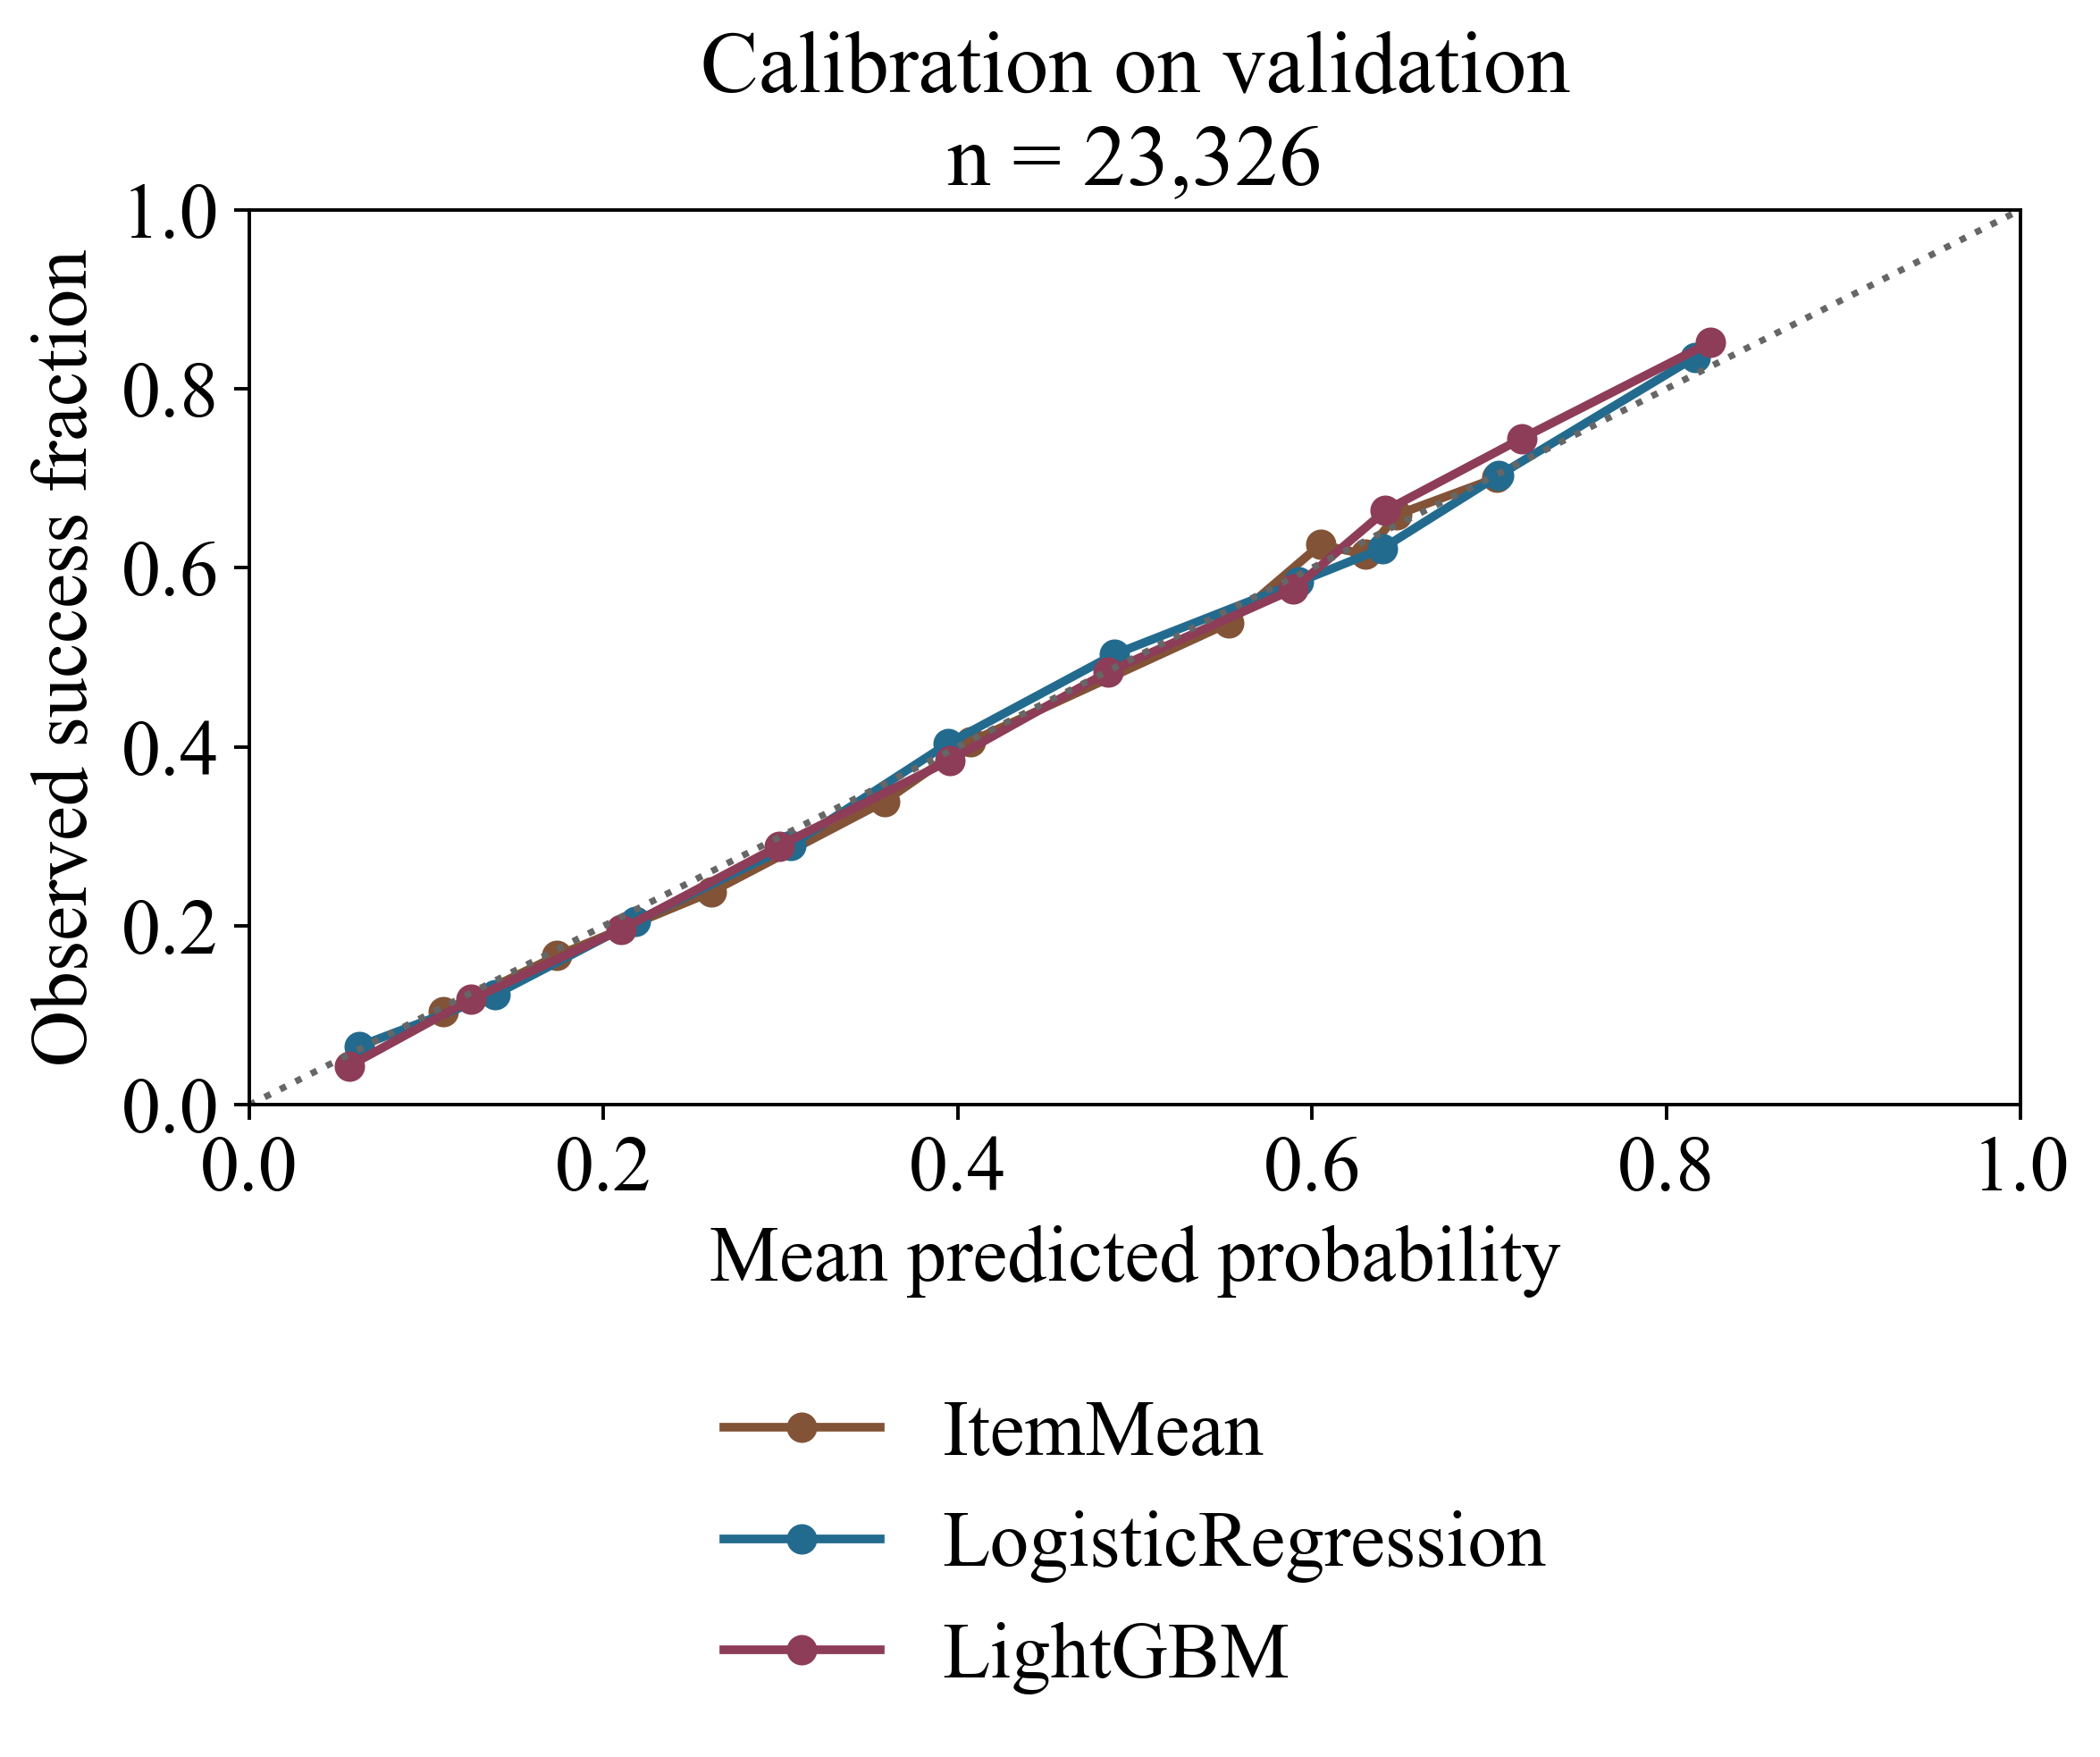

In [10]:
validation_metrics = metric_frame[metric_frame.Split.eq("Validation")]
mean_loss = validation_metrics.groupby("Model").LogLoss.mean()
best_tree = mean_loss.loc[["RandomForest", "XGBoost", "LightGBM"]].idxmin()
DIAGNOSTIC_MODELS = ["ItemMean", "LogisticRegression", best_tree]
COLORS = ["#825337", "#236B8E", "#8D3D58"]
ensemble_validation = (
    prediction_frame[prediction_frame.split.eq("Validation")]
    .groupby(["model", "id"], sort=False)
    .probability.mean()
)
fig, ax = plt.subplots(figsize=(6.6, 5.5), layout="constrained")
calibration_rows = []
for model_name, color in zip(DIAGNOSTIC_MODELS, COLORS):
    probability = (
        ensemble_validation.loc[model_name]
        .reindex(validation_data.id)
        .to_numpy()
    )
    observed, predicted = calibration_curve(
        validation_data.y, probability, n_bins=10, strategy="quantile"
    )
    ax.plot(
        predicted,
        observed,
        marker="o",
        color=color,
        linewidth=2,
        label=model_name,
    )
    calibration_rows.extend(
        {"Model": model_name, "Predicted": p, "Observed": o}
        for p, o in zip(predicted, observed)
    )
ax.plot([0, 1], [0, 1], linestyle=":", color="#666666")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed success fraction",
    title=f"Calibration on validation\nn = {len(validation_data):,}",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
pd.DataFrame(calibration_rows).to_csv(
    ROOT / "artifacts/03_calibration_curve.csv", index=False
)
save_figure(fig, "03_calibration")
plt.show()


Кривые трёх представленных моделей лежат близко к диагонали. Группировка вероятностей в десять интервалов даёт описательную диагностику: без интервалов неопределённости она не доказывает идеальную калибровку каждого значения вероятности.

## Ошибки при разной длине истории

Где усложнение модели приносит пользу: в режиме без контекста или после накопления опыта? Каждая точка — средняя потеря LogLoss в заранее фиксированной группе длины истории. Это описательная диагностика на validation; интервалы с кластеризацией по учащимся будут рассчитаны при итоговом сравнении.

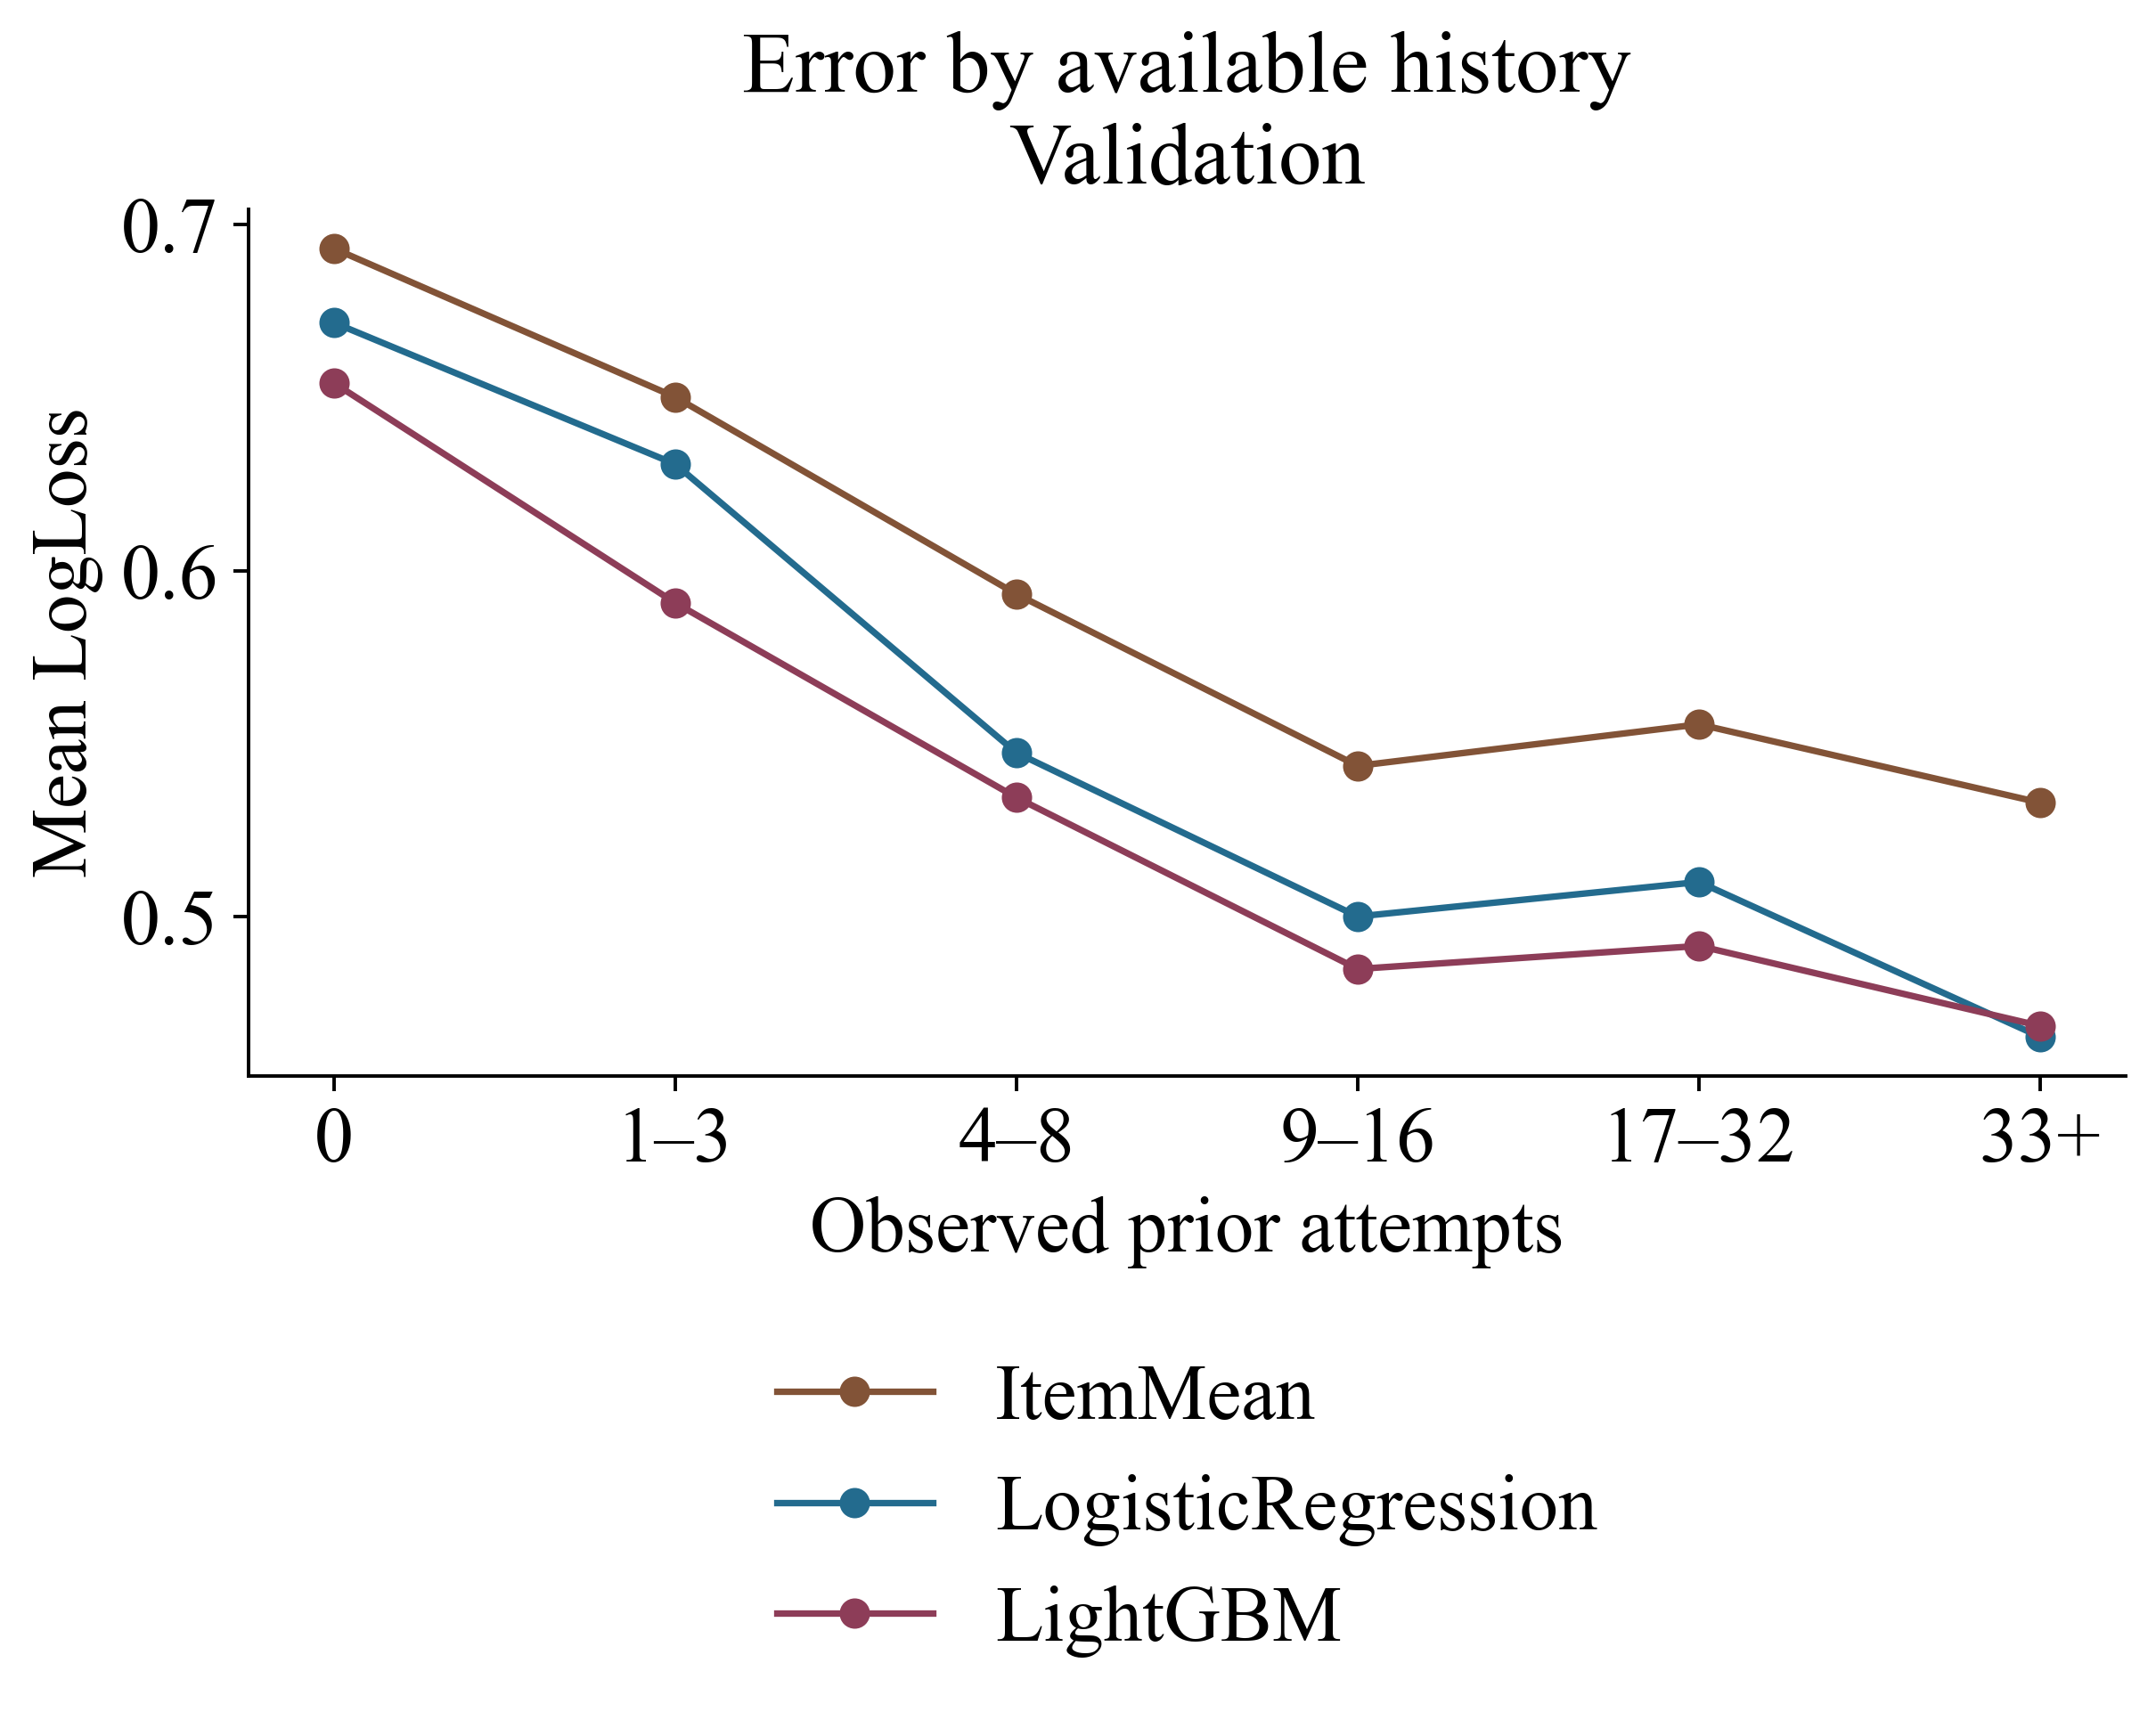

In [11]:
history_group = pd.cut(
    validation_data.history_n,
    bins=[-1, 0, 3, 8, 16, 32, np.inf],
    labels=["0", "1–3", "4–8", "9–16", "17–32", "33+"],
)
fig, ax = plt.subplots(figsize=(6.8, 5.4), layout="constrained")
regime_rows = []
for model_name, color in zip(DIAGNOSTIC_MODELS, COLORS):
    probability = (
        ensemble_validation.loc[model_name]
        .reindex(validation_data.id)
        .to_numpy()
    )
    probability = np.clip(
        probability, PROBABILITY_EPSILON, 1 - PROBABILITY_EPSILON
    )
    loss = -(
        validation_data.y * np.log(probability)
        + (1 - validation_data.y) * np.log1p(-probability)
    )
    grouped = (
        pd.DataFrame({"group": history_group, "loss": loss})
        .groupby("group", observed=False)
        .agg(n=("loss", "size"), LogLoss=("loss", "mean"))
        .reset_index()
    )
    ax.plot(
        np.arange(len(grouped)),
        grouped.LogLoss,
        color=color,
        marker="o",
        label=model_name,
    )
    grouped["Model"] = model_name
    regime_rows.append(grouped)
ax.set(
    xticks=np.arange(6),
    xticklabels=["0", "1–3", "4–8", "9–16", "17–32", "33+"],
    xlabel="Observed prior attempts",
    ylabel="Mean LogLoss",
    title="Error by available history\nValidation",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
ax.spines[["top", "right"]].set_visible(False)
pd.concat(regime_rows).to_csv(
    ROOT / "artifacts/03_history_error.csv", index=False
)
save_figure(fig, "03_error_by_history")
plt.show()


Наибольшая средняя ошибка наблюдается без предшествующей истории. LightGBM имеет меньший LogLoss в группах до 32 прошлых попыток; при 33 и более LogisticRegression немного лучше. Это делает адаптивное объединение разных механизмов проверяемой гипотезой, а не основанием заранее объявлять его выигрышным. Группы различаются также составом задач и учеников; наклон кривой нельзя интерпретировать как причинный эффект обучения.

## Эффективность табличных методов

Время включает обучение преобразований и оценку параметров на полном train. Время прогнозирования относится к уже преобразованному validation; стоимость preprocessing в него не включена. Размер сериализованной модели не является пиковым потреблением оперативной памяти. Значения зависят от текущей нагрузки на локальный компьютер.

In [12]:
efficiency_summary = (
    pd.DataFrame(efficiency_rows)
    .groupby(["Model", "Split", "n"], sort=False)
    .agg(
        Train_s=("Train seconds", "median"),
        Inference_s=("Prediction seconds", "median"),
        Model_MB=("Model MB", "median"),
    )
    .reset_index()
)
table(
    efficiency_summary,
    "Таблица 8. Измеренная вычислительная эффективность",
    "03_efficiency_summary",
)


Таблица 8. Измеренная вычислительная эффективность

,Model,Split,n,Train_s,Inference_s,Model_MB
0,LogisticRegression,Validation,23326,10.859,0.008,0.012
1,RandomForest,Validation,23326,6.863,0.102,15.300
2,XGBoost,Validation,23326,3.184,0.032,0.597
3,LightGBM,Validation,23326,3.633,0.219,0.795


Размер модели, время обучения и время прогнозирования характеризуют разные издержки. Измерения относятся к данному устройству и выбранной реализации; время инференса не включает предварительную обработку, а размер файла не является оценкой пиковой оперативной памяти. Малые различия времени без повторных измерений отдельного процесса не следует переинтерпретировать.

## Независимая школьная ветвь

Насколько сильны начальный балл и регуляризованная регрессия при переносе между школами? Используются только 18 допустимых входов. Сравниваются исходный pre-test, Ridge по pre-test, Ridge по всем входам и Random Forest. Параметры заранее фиксированы; OOF строится leave-one-school-out на четырёх школах train. Разбиения не смешиваются с основной задачей программирования.

In [13]:
school_training = pd.read_pickle(
    ROOT / "dataset/processed/school_train.pkl"
).reset_index(drop=True)
school_validation = pd.read_pickle(
    ROOT / "dataset/processed/school_validation.pkl"
).reset_index(drop=True)
school_contract = json.loads(
    (ROOT / "dataset/protocol/school_features.json").read_text()
)
school_features, school_target = (
    school_contract["features"],
    school_contract["target"],
)
pretest = school_contract["pretest"]


def school_pipeline(estimator, columns: list[str]):
    """Fit numeric imputation and grade encoding separately within each fold."""
    grade = "Students' grade"
    numeric = [column for column in columns if column != grade]
    transformations = [
        (
            "numeric",
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler(),
            ),
            numeric,
        )
    ]
    if grade in columns:
        transformations.append(
            (
                "grade",
                make_pipeline(
                    SimpleImputer(strategy="most_frequent"),
                    OneHotEncoder(
                        handle_unknown="ignore", sparse_output=False
                    ),
                ),
                [grade],
            )
        )
    return make_pipeline(ColumnTransformer(transformations), clone(estimator))


school_specs = [
    ("Pretest", None, [pretest]),
    ("RidgePretest", Ridge(alpha=10), [pretest]),
    ("RidgeFull", Ridge(alpha=10), school_features),
    (
        "RandomForest",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=6,
            min_samples_leaf=15,
            n_jobs=2,
            random_state=17,
        ),
        school_features,
    ),
]
school_rows, school_prediction_rows = [], []
for name, estimator, columns in school_specs:
    out_of_fold = np.full(len(school_training), np.nan)
    for school_group in sorted(school_training.school_group.unique()):
        held_out = school_training.school_group.eq(school_group)
        if estimator is None:
            out_of_fold[held_out] = school_training.loc[held_out, pretest]
        else:
            fitted = school_pipeline(estimator, columns)
            fitted.fit(
                school_training.loc[~held_out, columns],
                school_training.loc[~held_out, school_target],
            )
            out_of_fold[held_out] = fitted.predict(
                school_training.loc[held_out, columns]
            )
    if estimator is None:
        validation_prediction = school_validation[pretest].to_numpy()
    else:
        fitted = school_pipeline(estimator, columns)
        fitted.fit(school_training[columns], school_training[school_target])
        validation_prediction = fitted.predict(school_validation[columns])
        joblib.dump(
            {"model": fitted, "features": columns},
            MODEL_DIR / f"School_{name}.joblib",
        )
    for split, frame, predicted in [
        ("Train OOF", school_training, out_of_fold),
        ("Validation", school_validation, validation_prediction),
    ]:
        predicted = np.clip(predicted, 0, 24)
        truth = frame[school_target].to_numpy()
        school_rows.append(
            {
                "Model": name,
                "Split": split,
                "n": len(frame),
                "MAE ↓": mean_absolute_error(truth, predicted),
                "RMSE ↓": np.sqrt(mean_squared_error(truth, predicted)),
                "R² ↑": r2_score(truth, predicted),
            }
        )
        school_prediction_rows.append(
            pd.DataFrame(
                {
                    "source_row": frame.source_row,
                    "school": frame.school_group,
                    "Model": name,
                    "Split": split,
                    "target": truth,
                    "predicted": predicted,
                }
            )
        )
school_results = pd.DataFrame(school_rows)
pd.concat(school_prediction_rows).to_csv(
    ROOT / "artifacts/runtime/03_school_predictions.csv", index=False
)
table(
    school_results,
    "Таблица 9. Прогноз школьного результата",
    "03_school_results",
)


Таблица 9. Прогноз школьного результата

,Model,Split,n,MAE ↓,RMSE ↓,R² ↑
0,Pretest,Train OOF,909,3.590,4.596,0.093
1,Pretest,Validation,157,2.752,3.640,0.299
2,RidgePretest,Train OOF,909,2.862,3.671,0.421
3,RidgePretest,Validation,157,2.107,2.694,0.616
4,RidgeFull,Train OOF,909,3.211,4.128,0.268
5,RidgeFull,Validation,157,2.211,2.761,0.597
6,RandomForest,Train OOF,909,2.940,3.770,0.389
7,RandomForest,Validation,157,2.186,2.736,0.604


На одной validation-школе RidgePretest даёт MAE около 2,107 и RMSE около 2,694 — лучше RidgeFull и RandomForest. OOF по четырём обучающим школам также поддерживает простой вариант. Добавление анкетных признаков пока не обосновано результатами; возможны групповой сдвиг и ограниченность числа независимых школ.

## Сильные ориентиры для последующего сравнения

Выбор для дальнейшего анализа производится только по validation. Различия OOF и validation раскрываются отдельно; ни одно семейство не объявляется лучшим на закрытом тесте. Современные последовательные модели будут сравниваться на той же основной целевой выборке.

In [14]:
selection = (
    validation_metrics.groupby(["Model", "n"], sort=False)
    .agg(
        LogLoss=("LogLoss", "mean"),
        AUROC=("AUROC", "mean"),
        AP=("AP", "mean"),
        Brier=("Brier", "mean"),
    )
    .reset_index()
)
selection = selection.sort_values("LogLoss", kind="stable").reset_index(
    drop=True
)
selection.insert(1, "Split", "Validation")
selection["Rank"] = np.arange(1, len(selection) + 1)
selection.to_csv(
    ROOT / "artifacts/runtime/03_validation_selection.csv", index=False
)
table(
    selection[["Model", "Split", "n", "Rank", "LogLoss", "Brier"]],
    "Таблица 10. Ранжирование ориентиров по основной метрике",
    "03_baseline_selection",
)

(ROOT / "dataset/protocol/baseline_execution.json").write_text(
    json.dumps(
        {
            "feature_revision": contract["feature_revision"],
            "completed": True,
            "seeds": SEEDS,
        }
    )
);


Таблица 10. Ранжирование ориентиров по основной метрике

,Model,Split,n,Rank,LogLoss,Brier
0,LightGBM,Validation,23326,1,0.531,0.178
1,XGBoost,Validation,23326,2,0.533,0.179
2,RandomForest,Validation,23326,3,0.542,0.182
3,LogisticRegression,Validation,23326,4,0.550,0.185
4,ItemMean,Validation,23326,5,0.589,0.202
5,GlobalMean,Validation,23326,6,0.684,0.245


Для дальнейшего сравнения сохраняются LightGBM как сильнейший ML-ориентир, XGBoost как близкий конкурент и LogisticRegression как компактный интерпретируемый контроль. Их validation-ранжирование не является статистическим доказательством превосходства на будущих учениках.

## Граница выводов

Результаты характеризуют архивную задачу первого запуска при известном наборе заданий. Выбор семьи и последующее построение гибрида используют validation; заключение о превосходстве потребует однократной оценки после фиксации архитектуры на закрытом тесте. Школьная ветвь имеет только четыре обучающие школы и одну валидационную: ограничение независимых групп не устраняется большим числом учеников.